<a href="https://colab.research.google.com/github/Ajaykumar0502/-C-Users-ADMIN-Downloads-archive-insurance-claim-dashboard-design.pbix-/blob/main/Customer_LTV_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
# Install required libraries (if needed)
!pip install seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set_style("whitegrid")


In [54]:
# from google.colab import files
# uploaded = files.upload()


Saving Customer_DA.zip to Customer_DA (1).zip


In [72]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bornaetminan/churnguard-clean-and-ml-ready-telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churnguard-clean-and-ml-ready-telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/churnguard-clean-and-ml-ready-telco-customer-churn


In [73]:
df = pd.read_csv("/content/customer_churn_ml_ready.csv")
df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,gender_Male
0,0,1,0,-1.277445,0,0.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,True,False,False
1,0,0,0,0.066327,1,1.0,0.0,1.0,0.0,0.0,...,False,False,True,False,False,False,True,False,False,True
2,0,0,0,-1.236724,1,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,True
3,0,0,0,0.514251,0,1.0,0.0,1.0,1.0,0.0,...,False,False,True,False,False,False,False,True,False,True
4,0,0,0,-1.236724,1,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,False


In [74]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   float64
 4   PhoneService                           7043 non-null   int64  
 5   OnlineSecurity                         5517 non-null   float64
 6   OnlineBackup                           5517 non-null   float64
 7   DeviceProtection                       5517 non-null   float64
 8   TechSupport                            5517 non-null   float64
 9   StreamingTV                            5517 non-null   float64
 10  StreamingMovies                        5517 non-null   float64
 11  Pape

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
OnlineSecurity,1526
OnlineBackup,1526
DeviceProtection,1526
TechSupport,1526
StreamingTV,1526


In [75]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()
# df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
# Convert all categorical columns using get_dummies
df = pd.get_dummies(df, drop_first=True)

df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,gender_Male
0,0,1,0,-1.277445,0,0.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,True,False,False
1,0,0,0,0.066327,1,1.0,0.0,1.0,0.0,0.0,...,False,False,True,False,False,False,True,False,False,True
2,0,0,0,-1.236724,1,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,True
3,0,0,0,0.514251,0,1.0,0.0,1.0,1.0,0.0,...,False,False,True,False,False,False,False,True,False,True
4,0,0,0,-1.236724,1,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,False


In [76]:
# Convert all categorical columns using get_dummies
df = pd.get_dummies(df, drop_first=True)

df.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,gender_Male
0,0,1,0,-1.277445,0,0.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,True,False,False
1,0,0,0,0.066327,1,1.0,0.0,1.0,0.0,0.0,...,False,False,True,False,False,False,True,False,False,True
2,0,0,0,-1.236724,1,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,True
3,0,0,0,0.514251,0,1.0,0.0,1.0,1.0,0.0,...,False,False,True,False,False,False,False,True,False,True
4,0,0,0,-1.236724,1,0.0,0.0,0.0,0.0,0.0,...,True,False,False,False,False,True,False,False,False,False


In [77]:
churn_rate = df['Churn'].mean()
print("Churn Rate:", round(churn_rate * 100, 2), "%")


Churn Rate: nan %


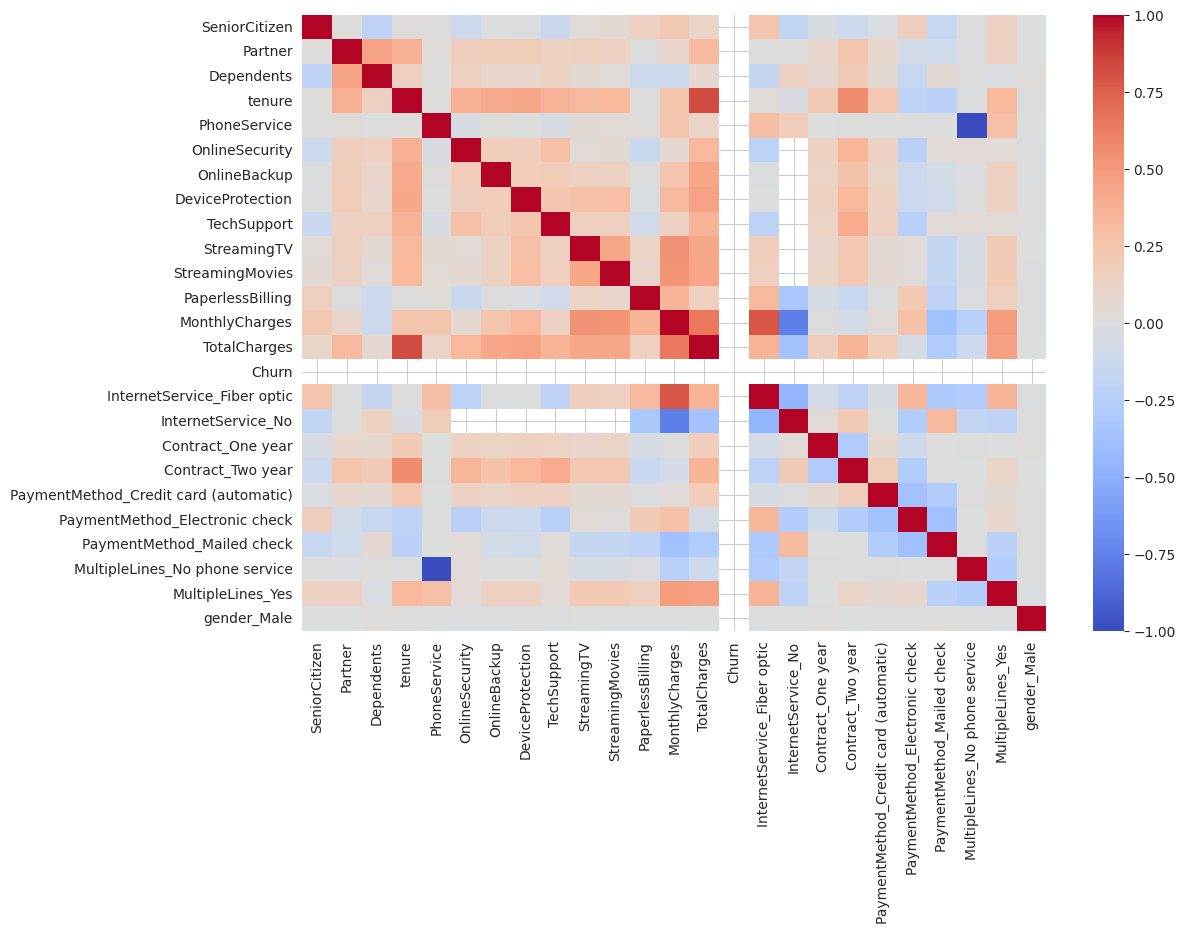

In [78]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


In [79]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [80]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Fix: Re-load data and perform correct preprocessing to handle NaNs and incorrect Churn mapping

# Re-loading the dataset to start with a clean state for 'df_fixed'
# Assuming the file path is correct based on previous execution logs.
df_fixed = pd.read_csv("/content/customer_churn_ml_ready.csv")

# Handle 'TotalCharges': Convert to numeric, coercing errors.
# Based on previous df.isnull().sum(), TotalCharges had 0 NaNs after coercion,
# but this step ensures robustness.
df_fixed['TotalCharges'] = pd.to_numeric(df_fixed['TotalCharges'], errors='coerce')
# Fill any potential NaNs created by coercion in 'TotalCharges' (e.g., with median or 0)
# The df.isnull().sum() showed 0 NaNs for TotalCharges, so this might not be strictly needed, but is good practice.
df_fixed['TotalCharges'].fillna(0, inplace=True) # Using 0 as a simple fill for now, median could also be used

# Correctly handle 'Churn' column: The df.info() showed 'Churn' is int64,
# so it's already numerical (0/1). The problematic .map() operation is skipped.
# No action needed for 'Churn' as it's already in the correct format for y.

# Impute NaN values in specific feature columns (OnlineSecurity, OnlineBackup, etc.) with 0.
cols_to_impute = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_to_impute:
    df_fixed[col] = df_fixed[col].fillna(0)

# Define X and y from the fixed dataframe
X_fixed = df_fixed.drop('Churn', axis=1)
y_fixed = df_fixed['Churn']

# Re-split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed, y_fixed, test_size=0.2, random_state=42
)

# Now, X_train and y_train should be clean and ready for fitting
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


/tmp/ipython-input-2274618425.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fixed['TotalCharges'].fillna(0, inplace=True) # Using 0 as a simple fill for now, median could also be used


LogisticRegression(max_iter=1000)

In [81]:
y_pred = model.predict(X_test)



In [82]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8211497515968772


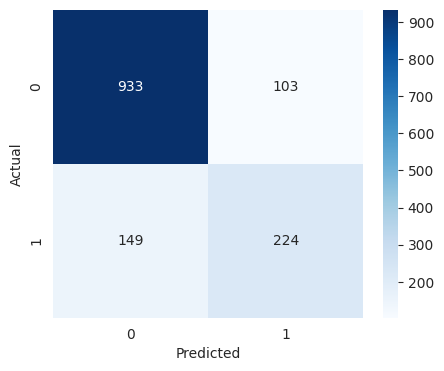

In [83]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [84]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [85]:
y_prob = model.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)


ROC-AUC Score: 0.8622058960530812


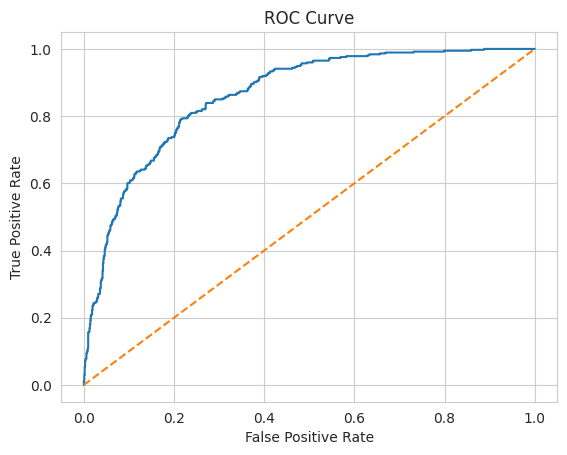

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [87]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)


,Feature,Coefficient
14,InternetService_Fiber optic,0.843525
13,TotalCharges,0.633766
11,PaperlessBilling,0.334998
19,PaymentMethod_Electronic check,0.321942
10,StreamingMovies,0.306897
22,MultipleLines_Yes,0.260105
9,StreamingTV,0.205304
0,SeniorCitizen,0.160433
1,Partner,0.053703
21,MultipleLines_No phone service,0.019548


In [88]:
X_test['Churn_Probability'] = y_prob
high_risk_customers = X_test[X_test['Churn_Probability'] > 0.7]

high_risk_customers.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No phone service,MultipleLines_Yes,gender_Male,Churn_Probability
6179,1,0,0,-0.870241,1,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,False,False,False,True,False,0.741547
3469,1,0,0,-0.707359,1,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,True,False,False,False,False,0.735979
4343,1,0,0,-0.992402,1,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,True,False,0.731844
6633,0,0,0,-1.277445,1,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,True,False,0.747285
2167,1,1,0,-0.788800,1,0.0,0.0,0.0,0.0,1.0,...,False,False,False,False,True,False,False,True,True,0.791569
